In [20]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import os
from dotenv import load_dotenv

In [21]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

multi_lexsum = load_dataset("allenai/multi_lexsum", name="v20230518", trust_remote_code=True, token=hf_token)

## 1. Data Exploration

Explore the Multi-LexSum dataset structure, feature statistics, and sample records.

In [22]:
# Dataset structure overview
print("Available splits:", list(multi_lexsum.keys()))
print("\nFeatures:")
print(multi_lexsum['train'].features)
print(f"\nSplit sizes:")
for split in multi_lexsum:
    print(f"  {split}: {len(multi_lexsum[split]):,} examples")

# Inspect a single record
sample = multi_lexsum['train'][0]
print("\n--- Sample record preview ---")
for k, v in sample.items():
    if isinstance(v, list):
        preview = f"[list of {len(v)} items; first 100 chars: {str(v[0])[:100]}...]"
    else:
        preview = str(v)[:200] if v is not None else "None"
    print(f"  {k}: {preview}")

Available splits: ['train', 'validation', 'test']

Features:
{'id': Value(dtype='string', id=None), 'sources': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'sources_metadata': Sequence(feature={'doc_id': Value(dtype='string', id=None), 'doc_type': Value(dtype='string', id=None), 'doc_title': Value(dtype='string', id=None), 'parser': Value(dtype='string', id=None), 'is_ocr': Value(dtype='bool', id=None), 'url': Value(dtype='string', id=None)}, length=-1, id=None), 'summary/long': Value(dtype='string', id=None), 'summary/short': Value(dtype='string', id=None), 'summary/tiny': Value(dtype='string', id=None), 'case_metadata': {'case_name': Value(dtype='string', id=None), 'case_type': Value(dtype='string', id=None), 'filing_date': Value(dtype='string', id=None), 'filing_year': Value(dtype='string', id=None), 'case_ongoing': Value(dtype='string', id=None), 'case_ongoing_record_time': Value(dtype='string', id=None), 'closing_year': Value(dtype='string', id=None), 'ord

In [23]:
import collections

KEY_SUMMARY_COLS = ['summary/long', 'summary/short', 'summary/tiny']
# Labels live inside the `case_metadata` dict, not at the top level
LABEL_COLS = ['class_action_sought', 'case_type']

first_ex = multi_lexsum['train'][0]
all_cols = list(first_ex.keys())
print("All columns:", all_cols)
print("case_metadata keys:", list(first_ex['case_metadata'].keys()))

# Null rates for summary columns
print("\nNull rates across splits:")
for split_name in multi_lexsum:
    split = multi_lexsum[split_name]
    total = len(split)
    for col in KEY_SUMMARY_COLS:
        null_count = sum(1 for ex in split if ex[col] is None or ex[col] == '')
        print(f"  {split_name}/{col}: {null_count}/{total} null ({100*null_count/total:.1f}%)")

# Label distributions (train only) — pulled from case_metadata
print("\nLabel distributions (train split):")
for col in LABEL_COLS:
    vals = [ex['case_metadata'].get(col) for ex in multi_lexsum['train']]
    vals = [v for v in vals if v is not None and v != '']
    counts = collections.Counter(vals)
    print(f"\n  {col}:")
    for label, cnt in counts.most_common(10):
        print(f"    {label!r}: {cnt}")

All columns: ['id', 'sources', 'sources_metadata', 'summary/long', 'summary/short', 'summary/tiny', 'case_metadata']
case_metadata keys: ['case_name', 'case_type', 'filing_date', 'filing_year', 'case_ongoing', 'case_ongoing_record_time', 'closing_year', 'order_start_year', 'order_end_year', 'defendant_payment', 'class_action_sought', 'class_action_granted', 'attorney_orgs', 'prevailing_party', 'plaintiff_types', 'plaintiff_description', 'constitutional_clauses', 'causes_of_action', 'summary_authors', 'case_url']

Null rates across splits:
  train/summary/long: 0/3177 null (0.0%)
  train/summary/short: 967/3177 null (30.4%)
  train/summary/tiny: 2047/3177 null (64.4%)
  validation/summary/long: 0/454 null (0.0%)
  validation/summary/short: 142/454 null (31.3%)
  validation/summary/tiny: 293/454 null (64.5%)
  test/summary/long: 0/908 null (0.0%)
  test/summary/short: 292/908 null (32.2%)
  test/summary/tiny: 596/908 null (65.6%)

Label distributions (train split):

  class_action_sought

## 2. Build DataFrame

Combine all three splits into a single pandas DataFrame with: full concatenated case text, three summary levels, `case_action_sought`, and `case_type`.

In [24]:
def build_dataframe(dataset_dict):
    rows = []
    for split_name, split in dataset_dict.items():
        for ex in split:
            sources = ex.get('sources') or []
            full_text = "\n\n".join(sources) if sources else ""
            meta = ex.get('case_metadata') or {}
            rows.append({
                'id': ex.get('id', ''),
                'split': split_name,
                'full_text': full_text,
                'summary_long':  ex.get('summary/long'),
                'summary_short': ex.get('summary/short'),
                'summary_tiny':  ex.get('summary/tiny'),
                'class_action_sought': meta.get('class_action_sought'),
                'case_type':           meta.get('case_type'),
            })
    return pd.DataFrame(rows)

df = build_dataframe(multi_lexsum)
print(f"Total rows: {len(df):,}")
print(f"\nNull counts per column:\n{df.isnull().sum()}")
print(f"\nSplit breakdown:\n{df['split'].value_counts()}")
print(f"\nclass_action_sought distribution:\n{df['class_action_sought'].value_counts(dropna=False)}")
print(f"\ncase_type top 5:\n{df['case_type'].value_counts(dropna=False).head()}")
df.head(2)

Total rows: 4,539

Null counts per column:
id                        0
split                     0
full_text                 0
summary_long              0
summary_short          1401
summary_tiny           2936
class_action_sought       0
case_type                 0
dtype: int64

Split breakdown:
split
train         3177
test           908
validation     454
Name: count, dtype: int64

class_action_sought distribution:
class_action_sought
No         3026
Yes        1510
Unknown       3
Name: count, dtype: int64

case_type top 5:
case_type
Equal Employment                         1579
Immigration and/or the Border             523
Prison Conditions                         424
Jail Conditions                           303
Public Benefits / Government Services     288
Name: count, dtype: int64


,id,split,full_text,summary_long,summary_short,summary_tiny,class_action_sought,case_type
0,EE-AL-0045,train,Case 1:05-cv-00530-D Document 1-1 Filed 09/19/...,"On September 15, 2005, the Equal Employment Op...",Equal Employment Opportunity Commission brough...,NaN,No,Equal Employment
1,PB-NJ-0003,train,Case 3:05-cv-01784-SRC-JJH Document 2 Filed 05...,NOTE: This is one of three identically named ...,The case was brought by a non-profit organizat...,NaN,No,Public Benefits / Government Services


## 3. Text Cleaning

A two-stage pipeline:

1. **Legal-domain pre-cleaning** — strip court headers, docket numbers, U.S.C. citations, and reporter citations (`123 F.3d 456`). These are high-frequency tokens that carry no semantic case content; removing them lets TF-IDF surface substantive vocabulary.
2. **NLTK normalization** (the canonical course pipeline from *week 3 — Text Normalization with NLTK*): `word_tokenize` → punctuation removal → lowercase → alpha-only filter → stopword removal → **WordNet lemmatization**.

Two output columns are produced:

- `prepped_text` — boilerplate-stripped but still grammatical (used downstream by the **abstractive summarizer**, which needs readable sentences).
- `clean_text` — fully NLTK-normalized (used by the **classifiers** via TF-IDF).

In [25]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

for resource in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"):
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource, quiet=True)

_LEMMATIZER = WordNetLemmatizer()
_STOPWORDS  = set(stopwords.words("english"))
_PUNCT_RE   = re.compile(f"[{re.escape(string.punctuation)}]")

# Legal-domain boilerplate regexes — applied BEFORE NLTK normalization
_BOILERPLATE_PATTERNS = [
    re.compile(r"\b(?:No\.|Case)\s+\d+[\d:\-cvCV]*\b"),          # "Case 1:05-cv-00530-D", "No. 12-cv-1234"
    re.compile(r"\d+\s+U\.S\.C\.\s*§?\s*\d+(?:\([a-z0-9]+\))*"), # "42 U.S.C. § 1983"
    re.compile(r"\d+\s+[A-Z]\.\s?\d?[a-z]?\s+\d+"),               # "123 F.3d 456" (reporter citations)
    re.compile(r"(?:UNITED STATES|U\.S\.)\s+(?:DISTRICT|COURT OF APPEALS)[^\n]*", re.IGNORECASE),
    re.compile(r"Document\s+\d+(?:-\d+)?\s+Filed\s+\d{1,2}/\d{1,2}/\d{2,4}"),  # docket header lines
    re.compile(r"Page\s+\d+\s+of\s+\d+", re.IGNORECASE),
    re.compile(r"<[^>]+>"),                                       # HTML/XML tags
]

def strip_legal_boilerplate(text: str) -> str:
    """Strip court headers, docket numbers, and statutory citations."""
    if not text:
        return ""
    for pat in _BOILERPLATE_PATTERNS:
        text = pat.sub(" ", text)
    text = text.encode("ascii", "ignore").decode()        # drop non-ASCII
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text(text: str) -> str:
    """Full NLTK pipeline: tokenize → strip punctuation → lowercase → alpha → stopwords → lemmatize."""
    if not text:
        return ""
    tokens = word_tokenize(text)
    tokens = [_PUNCT_RE.sub("", t) for t in tokens]
    tokens = [t.lower() for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in _STOPWORDS and len(t) > 2]
    tokens = [_LEMMATIZER.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["prepped_text"] = df["full_text"].apply(strip_legal_boilerplate)
df["clean_text"]   = df["prepped_text"].apply(clean_text)

print(f"prepped_text — mean length: {df['prepped_text'].str.len().mean():>12,.0f} chars")
print(f"clean_text   — mean length: {df['clean_text'].str.len().mean():>12,.0f} chars")
print(f"clean_text   — mean tokens: {df['clean_text'].str.split().str.len().mean():>12,.0f}")
print(f"\n--- BEFORE (raw, first 350 chars) ---\n{df['full_text'].iloc[0][:350]}")
print(f"\n--- prepped_text (first 350 chars) ---\n{df['prepped_text'].iloc[0][:350]}")
print(f"\n--- clean_text (first 350 chars) ---\n{df['clean_text'].iloc[0][:350]}")

prepped_text — mean length:      328,828 chars
clean_text   — mean length:      215,249 chars
clean_text   — mean tokens:       27,362

--- BEFORE (raw, first 350 chars) ---
Case 1:05-cv-00530-D Document 1-1 Filed 09/19/2005 Page 1 of 6

IN

THE

UNITED

STATES

DISTRICT

FILD COUR T

P19

.05

Nl

el

.s

FOR THE SOUTHERN DISTRICT OF ALABAMA

SOUTHERN DIVISION

EQUAL EMPLOYMENT OPPORTUNITY ]

COMMISSION, ]

] Plaintiff, ] Civil Action No. OSS- 0'53a -~

v.

]

]
COMPLAINT

] HOUSE OF PHILADELPHIA CENTER, INC . ]

JURY

--- prepped_text (first 350 chars) ---
D IN THE UNITED STATES DISTRICT FILD COUR T P19 .05 Nl el .s FOR THE SOUTHERN DISTRICT OF ALABAMA SOUTHERN DIVISION EQUAL EMPLOYMENT OPPORTUNITY ] COMMISSION, ] ] Plaintiff, ] Civil Action No. OSS- 0'53a -~ v. ] ] COMPLAINT ] HOUSE OF PHILADELPHIA CENTER, INC . ] JURY TRIAL DEMAND Defendant . ] ] ] ] NATURE OF THE ACTION This is an action under Tit

--- clean_text (first 350 chars) ---
united state district fild cour southern distr

## 4. TF-IDF Extractive Excerpt

The abstractive summarizer used in §5 has a hard **1,024-token input window**. The cleaned cases average ~50,000 words — so naively truncating to the first 1,024 tokens means the model only ever sees a procedural header (court name, docket number, filing block).

We use an **extractive summarization** pre-step (a course-covered NLP algorithm): per-document TF-IDF sentence scoring. Sentences are ranked by mean TF-IDF weight, the top-scoring ones are greedily packed until a 480-token budget is exhausted, then re-ordered to match their original positions in the document.

This produces a `excerpt` column that fits the model's window while keeping the highest-signal sentences from *anywhere* in the case, not just the opening pages. The excerpt is the input to the abstractive summarizer in §5; the full NLTK-normalized `clean_text` is the input to the classifiers in §7 and §8.

In [26]:
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm

def build_excerpt(text: str, max_tokens: int = 480) -> str:
    """Extractive summarization via per-document TF-IDF sentence ranking.

    Returns the top-scoring sentences (in original order) that fit in `max_tokens` whitespace tokens.
    """
    if not text or not text.strip():
        return ""

    # Hard character cap protects against pathological 1M+ char cases (NLTK is O(n))
    sentences = sent_tokenize(text[:300_000])
    if len(sentences) <= 1:
        return " ".join(text.split()[:max_tokens])

    try:
        vec = TfidfVectorizer(stop_words="english")
        tfidf = vec.fit_transform(sentences)
    except ValueError:
        return " ".join(text.split()[:max_tokens])

    scores = tfidf.mean(axis=1).A1
    ranked = scores.argsort()[::-1]

    chosen, used = [], 0
    for idx in ranked:
        n = len(sentences[idx].split())
        if used + n > max_tokens:
            continue
        chosen.append(idx)
        used += n
        if used >= max_tokens:
            break

    chosen.sort()
    return " ".join(sentences[i] for i in chosen)

tqdm.pandas(desc="Building excerpts")
df["excerpt"] = df["prepped_text"].progress_apply(build_excerpt)

excerpt_tokens = df["excerpt"].str.split().str.len()
print(f"Excerpt token count — mean: {excerpt_tokens.mean():.0f}, max: {excerpt_tokens.max()}, min: {excerpt_tokens.min()}")
assert excerpt_tokens.max() <= 512, "Excerpt exceeded budget"
print(f"\n--- Excerpt for case {df['id'].iloc[0]} (first 600 chars) ---\n{df['excerpt'].iloc[0][:600]}")

Building excerpts:   0%|          | 0/4539 [00:00<?, ?it/s]

Excerpt token count — mean: 480, max: 480, min: 477

--- Excerpt for case EE-AL-0045 (first 600 chars) ---
10. Defendant and its officers, agents, employees, successors, and assigns both at the time that this Decree becomes effective and for the duration of this Decree agree to comply with Federal law and acknowledge that it is unlawful to: (a) discriminate against any employee on the basis of pregnancy or sex, (b) harass any employee based on pregnancy or sex; (c) retaliate against any employee because he or she: (i) opposes or opposed discriminatory practices nlade unlawful by Title VII; (ii) files or filed a charge of discrimination or assists, assisted, 2 participates, or participated in the fi


## 5. Cascade Abstractive Summarization

Two-stage NLP pipeline:

1. **Extractive (§4):** TF-IDF sentence ranking selects the 480 most-informative tokens.
2. **Abstractive (here):** **DistilBART-CNN-12-6** (a distilled seq2seq transformer) rewrites those tokens at three target granularities.

We use a **cascade** that mirrors how the Multi-LexSum experts authored the ground truth:

```
excerpt ──BART──▶ summary_long_gen ──BART──▶ summary_short_gen ──BART──▶ summary_tiny_gen
```

Each tier is summarized *from the previous tier's output*, not independently from the excerpt. This is the same hierarchical pattern used in the dataset's annotation guidelines and makes the ROUGE comparison in §6 a fair test of the model — generated and reference summaries are produced by structurally analogous processes.

Beam search (`num_beams=4`) and tri-gram blocking (`no_repeat_ngram_size=3`) suppress the repetitive degenerate text that vanilla greedy decoding produces on legal prose.

In [27]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "sshleifer/distilbart-cnn-12-6"
_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
_model.eval()

# (max_new_tokens, min_new_tokens) per tier
TIER_LENGTHS = {
    "long":  (250, 100),
    "short": (100,  40),
    "tiny":  ( 40,  15),
}

def _bart_summarize(text: str, max_new: int, min_new: int) -> str:
    """Single BART decode pass with beam search and tri-gram blocking."""
    inputs = _tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    with torch.no_grad():
        out = _model.generate(
            **inputs,
            max_new_tokens=max_new,
            min_new_tokens=min_new,
            num_beams=4,
            no_repeat_ngram_size=3,
            early_stopping=True,
        )
    return _tokenizer.decode(out[0], skip_special_tokens=True).strip()

def generate_summaries(excerpt: str) -> dict[str, str]:
    """Cascade: excerpt → long → short → tiny. Mirrors how Multi-LexSum experts authored the data."""
    if not excerpt or len(excerpt.split()) < 30:
        return {tier: excerpt for tier in TIER_LENGTHS}
    long_  = _bart_summarize(excerpt, *TIER_LENGTHS["long"])
    short_ = _bart_summarize(long_,   *TIER_LENGTHS["short"])
    tiny_  = _bart_summarize(short_,  *TIER_LENGTHS["tiny"])
    return {"long": long_, "short": short_, "tiny": tiny_}

# Demo on 3 training cases that have expert tiny summaries
demo = df[(df["split"] == "train") & df["summary_tiny"].notna()].head(3)
for _, row in demo.iterrows():
    gen = generate_summaries(row["excerpt"])
    print(f"\n{'=' * 72}\nCase {row['id']}\n{'=' * 72}")
    for tier in ("long", "short", "tiny"):
        print(f"\n[gen-{tier}]   {gen[tier]}")
    print(f"\n[expert-tiny] {row['summary_tiny']}")

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=250) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=100) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co


Case PB-WV-0002

[gen-long]   Complaint by Vera J. McCormick, Karen S. Cole filed 10/01/2013 and was terminated 11/07/2014 Jury Demand: None . Judge Robert C. Chambers ruled that Plaintiffs' claims as to the other portions of the marriage ban may proceed . Heavily-worded ruling reserving ruling as to whether the existing Defendants are sufficient to bind state authorities and all county clerks, should a ruling on the merits be made in favor of Plaintiffs . The Court will not consider legal argument presented in the memorandum accompanying those exhibits; the Court will consider the two exhibits attached to Plaintiffs’ notice of supplemental authority .

[gen-short]   Judge Robert C. Chambers ruled that Plaintiffs' claims as to the other portions of the marriage ban may proceed . Heavily-worded ruling reserving ruling as to whether existing Defendants are sufficient to bind state authorities and all county clerks .

[gen-tiny]   Judge Robert C. Chambers ruled that Plaintiffs' claims as

[transformers] Both `max_new_tokens` (=250) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=100) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co


Case PN-MI-0008

[gen-long]   Enter a judgment declaring that Defendants Guerrero and McCarthy violated 19 PLM Doc #1 Filed 05/01/13 Page ID#20 Plaintiff Webers clearly established constitutional rights by arresting him for criminal trespassing in the absence of probable cause . Issue a permanent injunction restraining Defendants, their employees, agents, and successors from continuing to use generalized Letters of Intent as a basis for making individual trespass arrests . Award damages to the Plaintiffs to compensate them for the indignity of being subjected to an unlawful arrest; time spent in jail as a result of the unlawful arrest .

[gen-short]   Plaintiff Webers clearly established constitutional rights by arresting him for criminal trespassing in the absence of probable cause . Issue a permanent injunction restraining Defendants, their employees, agents, and successors from continuing to use generalized Letters of Intent as a basis for making individual trespass arrests . Award

[transformers] Both `max_new_tokens` (=250) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=100) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co


Case PC-MI-0036

[gen-long]   Plaintiffs Mary Ann McBride and the other named Plaintiffs, on behalf of themselves and the class of deaf and hard of hearing individuals certified by the Court (the Class), and Defendant Michigan Department of Corrections . Michigan Protection and Advocacy Service, Inc. filed a joint motion for preliminary approval of the class action settlement agreement, and set a date for a fairness hearing on the proposed Settlement Agreement in accordance with Rule 23(e) of the Federal Rules of Civil Procedure . The parties filed the motion for an Order, pursuant to Rule 23, of the federal rules of civil procedure, to grant preliminary approval .

[gen-short]   Michigan Protection and Advocacy Service, Inc. filed a joint motion for preliminary approval of the class action settlement agreement . The parties filed the motion for an Order, pursuant to Rule 23, of the federal rules of civil procedure, to grant preliminary approval .

[gen-tiny]   Michigan Protection and

## 6. ROUGE Evaluation

Quantitative comparison of generated vs. expert-authored summaries, using the standard summarization metrics:

- **ROUGE-1** — unigram F1 overlap (lexical coverage of content words)
- **ROUGE-2** — bigram F1 overlap (phrasal fidelity)
- **ROUGE-L** — longest-common-subsequence F1 (structural/word-order similarity)

To keep this tractable inside the notebook (each cascade run is ~10–15 seconds on CPU), we evaluate on a stratified 50-case sample drawn from the validation split. The same code runs over the full split if executed on a GPU.

We report per-tier mean scores and surface the best and worst cases by ROUGE-1 to surface qualitative patterns for the presentation.

In [28]:
# pip install rouge-score
from rouge_score import rouge_scorer

ROUGE_KEYS = ("rouge1", "rouge2", "rougeL")
_scorer = rouge_scorer.RougeScorer(list(ROUGE_KEYS), use_stemmer=True)

def rouge_row(reference: str | None, candidate: str | None) -> dict[str, float | None]:
    if not isinstance(reference, str) or not isinstance(candidate, str) or not reference or not candidate:
        return {k: None for k in ROUGE_KEYS}
    s = _scorer.score(reference, candidate)
    return {k: s[k].fmeasure for k in ROUGE_KEYS}

# Stratified 50-case sample from the validation split with at least a short summary present
SAMPLE_N = 50
eval_pool = df[(df["split"] == "validation") & df["summary_short"].notna()]
if len(eval_pool) > SAMPLE_N:
    eval_pool = eval_pool.sample(n=SAMPLE_N, random_state=42)

print(f"Generating cascade summaries for {len(eval_pool)} cases (this takes a few minutes on CPU)...")
gen_rows = []
for _, row in tqdm(eval_pool.iterrows(), total=len(eval_pool), desc="Cascade summarize"):
    gen = generate_summaries(row["excerpt"])
    gen_rows.append({"id": row["id"], **{f"gen_{k}": v for k, v in gen.items()}})

gen_df = pd.DataFrame(gen_rows).set_index("id")
eval_df = eval_pool.set_index("id").join(gen_df)

rouge_records = []
for tier, ref_col, gen_col in [
    ("long",  "summary_long",  "gen_long"),
    ("short", "summary_short", "gen_short"),
    ("tiny",  "summary_tiny",  "gen_tiny"),
]:
    for cid, row in eval_df.iterrows():
        scores = rouge_row(row[ref_col], row[gen_col])
        rouge_records.append({"id": cid, "tier": tier, **scores})

rouge_df = pd.DataFrame(rouge_records).dropna(subset=list(ROUGE_KEYS))

print("\n=== Mean ROUGE F1 by tier ===")
mean_table = rouge_df.groupby("tier")[list(ROUGE_KEYS)].mean().round(3)
mean_table["n_pairs"] = rouge_df.groupby("tier").size()
print(mean_table.loc[["long", "short", "tiny"]])

print("\n=== Best long summary (by ROUGE-1) ===")
best = rouge_df[rouge_df.tier == "long"].nlargest(1, "rouge1").iloc[0]
case = eval_df.loc[best["id"]]
print(f"ROUGE-1 {best.rouge1:.3f} | ROUGE-2 {best.rouge2:.3f} | ROUGE-L {best.rougeL:.3f}")
print(f"\nExpert long (first 350 chars):\n{(case['summary_long'] or '')[:350]}")
print(f"\nGenerated long (first 350 chars):\n{(case['gen_long'] or '')[:350]}")

Generating cascade summaries for 50 cases (this takes a few minutes on CPU)...


Cascade summarize:   0%|          | 0/50 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=250) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=100) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=142) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `min_new_tokens` (=40) and `min_length`(=56) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co


=== Mean ROUGE F1 by tier ===
       rouge1  rouge2  rougeL  n_pairs
tier                                  
long    0.116   0.030   0.068       50
short   0.162   0.031   0.102       50
tiny    0.119   0.024   0.090       33

=== Best long summary (by ROUGE-1) ===
ROUGE-1 0.372 | ROUGE-2 0.114 | ROUGE-L 0.208

Expert long (first 350 chars):
On April 14, 2004, individuals and an advocacy organization filed this First Amendment case in the U.S. District Court for the Eastern District of New Orleans against Jefferson Parish claiming the Parish had unfairly applied parish ordinances (including one known as "the circus ordinance") to squelch pro-life speech. the plaintiffs were represented

Generated long (first 350 chars):
Alliance Defense Fund sues Jefferson Parish officials in light of ADF lawsuit . Jefferson Parish Council agreed to a settlement instead of going to court to defend their actions in Related News interfering with the free speech rights of organizers of a pro-life Jefferso

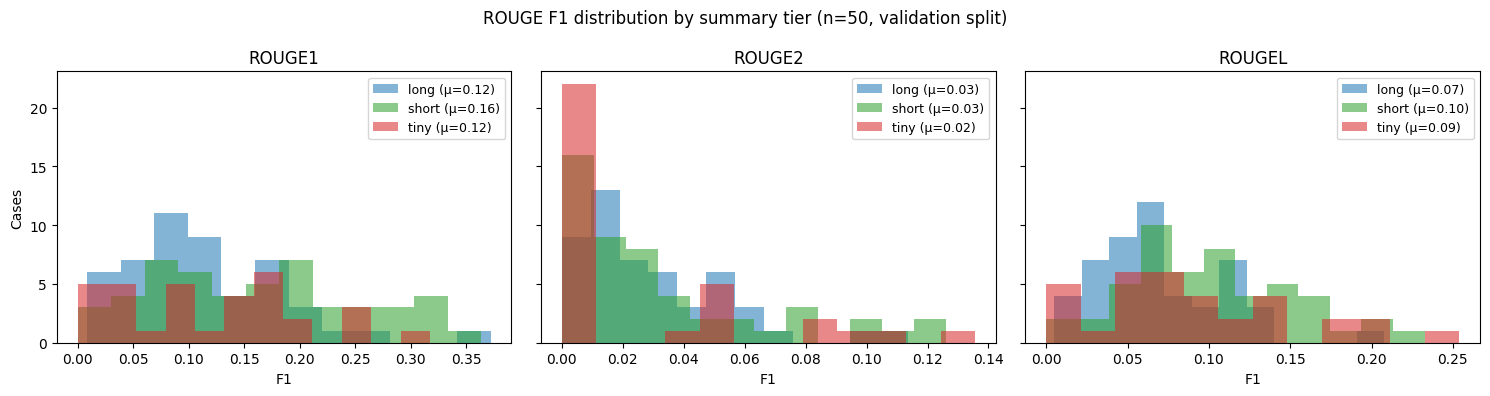

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric in zip(axes, ROUGE_KEYS):
    for tier, color in [("long", "#1f77b4"), ("short", "#2ca02c"), ("tiny", "#d62728")]:
        vals = rouge_df.loc[rouge_df.tier == tier, metric]
        ax.hist(vals, bins=12, alpha=0.55, label=f"{tier} (μ={vals.mean():.2f})", color=color)
    ax.set_title(metric.upper())
    ax.set_xlabel("F1")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("Cases")
fig.suptitle("ROUGE F1 distribution by summary tier (n=50, validation split)")
plt.tight_layout()
plt.show()

## 7. Classification — `class_action_sought`

Binary task (`Yes`/`No`). Three-tier model progression covers every model family the course requires:

| Model | Family | Why included |
|---|---|---|
| Multinomial Naive Bayes | Probabilistic | Course baseline — fast, interpretable, well-suited to TF-IDF features |
| Logistic Regression | Generalized linear | Coefficient-interpretable; production model used by the interactive tool |
| PyTorch dense NN | Deep learning | Satisfies the "must have a neural network" requirement; trained on TF-IDF features |

**Splits.** We use the **dataset's own** train/validation/test splits (no internal re-splitting), so results are directly comparable to published Multi-LexSum benchmarks and across our two classification targets. `class_weight='balanced'` is applied to LR to compensate for the 2:1 No:Yes imbalance.

A DistilBERT fine-tuning section follows in §8 for the deep-NLP requirement.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, log_loss
from sklearn.preprocessing import LabelEncoder

LABEL_VALUES = ["Yes", "No"]

def split_for(label_col: str):
    mask = df[label_col].isin(LABEL_VALUES) & (df["clean_text"].str.len() > 50)
    sub = df[mask]
    parts = {s: sub[sub["split"] == s] for s in ("train", "validation", "test")}
    return parts

parts = split_for("class_action_sought")
X_train, y_train = parts["train"]["clean_text"],      parts["train"]["class_action_sought"]
X_val,   y_val   = parts["validation"]["clean_text"], parts["validation"]["class_action_sought"]
X_test,  y_test  = parts["test"]["clean_text"],       parts["test"]["class_action_sought"]
print(f"Train / Val / Test rows: {len(X_train)} / {len(X_val)} / {len(X_test)}")

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print("\n--- Naive Bayes (validation) ---")
print(classification_report(y_val, nb.predict(X_val_tfidf), digits=3))
print(f"Log loss: {log_loss(y_val, nb.predict_proba(X_val_tfidf)):.3f}")

lr = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced")
lr.fit(X_train_tfidf, y_train)
print("\n--- Logistic Regression (validation) ---")
print(classification_report(y_val, lr.predict(X_val_tfidf), digits=3))
print(f"Log loss: {log_loss(y_val, lr.predict_proba(X_val_tfidf)):.3f}")

print("\n=== Held-out TEST accuracy ===")
for name, model in [("Naive Bayes", nb), ("Logistic Regression", lr)]:
    print(f"  {name:<22} {model.score(X_test_tfidf, y_test):.3f}")

Train / Val / Test rows: 3175 / 453 / 908

--- Naive Bayes (validation) ---
              precision    recall  f1-score   support

          No      0.956     0.725     0.824       298
         Yes      0.639     0.935     0.759       155

    accuracy                          0.797       453
   macro avg      0.797     0.830     0.792       453
weighted avg      0.847     0.797     0.802       453

Log loss: 0.507

--- Logistic Regression (validation) ---
              precision    recall  f1-score   support

          No      0.969     0.956     0.963       298
         Yes      0.918     0.942     0.930       155

    accuracy                          0.951       453
   macro avg      0.944     0.949     0.946       453
weighted avg      0.952     0.951     0.952       453

Log loss: 0.223

=== Held-out TEST accuracy ===
  Naive Bayes            0.808
  Logistic Regression    0.968


Epoch  1 | train_acc 0.7987 | val_acc 0.9139
Epoch  2 | train_acc 0.9427 | val_acc 0.9360
Epoch  3 | train_acc 0.9650 | val_acc 0.9558
Epoch  4 | train_acc 0.9776 | val_acc 0.9558
Epoch  5 | train_acc 0.9865 | val_acc 0.9558
Epoch  6 | train_acc 0.9887 | val_acc 0.9558
Epoch  7 | train_acc 0.9912 | val_acc 0.9558
Epoch  8 | train_acc 0.9956 | val_acc 0.9514
Epoch  9 | train_acc 0.9962 | val_acc 0.9492
Epoch 10 | train_acc 0.9969 | val_acc 0.9514


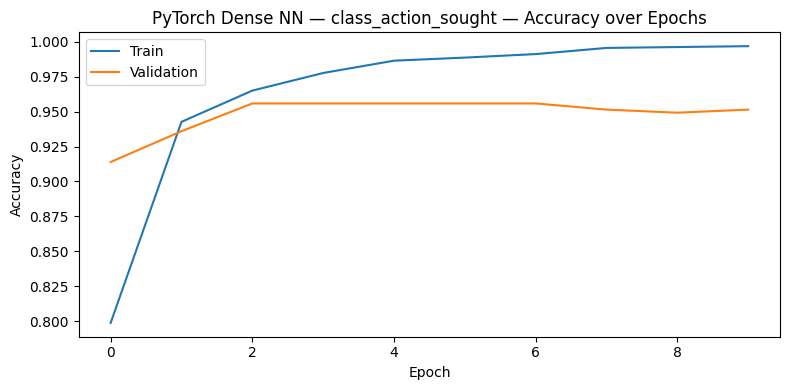

--- PyTorch Dense NN (validation) ---
              precision    recall  f1-score   support

          No      0.960     0.966     0.963       298
         Yes      0.935     0.923     0.929       155

    accuracy                          0.951       453
   macro avg      0.947     0.945     0.946       453
weighted avg      0.951     0.951     0.951       453

Test accuracy: 0.968


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

le_action = LabelEncoder()
y_train_enc = le_action.fit_transform(y_train)
y_val_enc   = le_action.transform(y_val)
y_test_enc  = le_action.transform(y_test)

X_train_dense = torch.tensor(X_train_tfidf.toarray().astype("float32"))
X_val_dense   = torch.tensor(X_val_tfidf.toarray().astype("float32"))
X_test_dense  = torch.tensor(X_test_tfidf.toarray().astype("float32"))

train_action_ds     = TensorDataset(X_train_dense, torch.tensor(y_train_enc, dtype=torch.long))
val_action_ds       = TensorDataset(X_val_dense,   torch.tensor(y_val_enc,   dtype=torch.long))
train_action_loader = DataLoader(train_action_ds, batch_size=32, shuffle=True)
val_action_loader   = DataLoader(val_action_ds,   batch_size=32)

n_features = X_train_dense.shape[1]
n_classes  = len(le_action.classes_)

model_action = nn.Sequential(
    nn.Linear(n_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, n_classes),
)

criterion_action = nn.CrossEntropyLoss()
optimizer_action = optim.Adam(model_action.parameters())

train_accs, val_accs = [], []
for epoch in range(10):
    model_action.train()
    correct, total = 0, 0
    for Xb, yb in train_action_loader:
        optimizer_action.zero_grad()
        out = model_action(Xb)
        loss = criterion_action(out, yb)
        loss.backward()
        optimizer_action.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += len(yb)
    train_accs.append(correct / total)

    model_action.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_action_loader:
            out = model_action(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += len(yb)
    val_accs.append(correct / total)
    print(f"Epoch {epoch+1:2d} | train_acc {train_accs[-1]:.4f} | val_acc {val_accs[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_accs, label="Train")
plt.plot(val_accs,   label="Validation")
plt.title("PyTorch Dense NN — class_action_sought — Accuracy over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.tight_layout(); plt.show()

model_action.eval()
with torch.no_grad():
    preds_val_action  = le_action.inverse_transform(model_action(X_val_dense).argmax(1).numpy())
    preds_test_action = le_action.inverse_transform(model_action(X_test_dense).argmax(1).numpy())

print("--- PyTorch Dense NN (validation) ---")
print(classification_report(y_val, preds_val_action, digits=3))
print(f"Test accuracy: {(preds_test_action == y_test.values).mean():.3f}")

### 7.1 Coefficient polarity — what does the LR model key on?

Because TF-IDF features are bigrams and LR is convex, the fitted coefficients are directly interpretable as per-class log-odds contributions. The top positive / negative terms below are the **evidence the production model uses** when classifying a new case — a much more presentable answer than "the model accuracy is 0.94".

In [32]:
feature_names = vectorizer.get_feature_names_out()
# sklearn LR with 2 classes stores a single (1, n_features) coefficient vector;
# positive coef → higher log-odds for classes_[1], negative → higher for classes_[0]
coefs = lr.coef_[0]
order = coefs.argsort()
positive_cls = lr.classes_[1]
negative_cls = lr.classes_[0]

top_pos = pd.DataFrame({
    "term": feature_names[order[-20:][::-1]],
    "coef": coefs[order[-20:][::-1]],
})
top_neg = pd.DataFrame({
    "term": feature_names[order[:20]],
    "coef": coefs[order[:20]],
})

print(f"=== Top 20 terms pushing prediction toward '{positive_cls}' ===")
print(top_pos.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))
print(f"\n=== Top 20 terms pushing prediction toward '{negative_cls}' ===")
print(top_neg.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

=== Top 20 terms pushing prediction toward 'Yes' ===
                term   coef
        class member +4.851
        class action +4.608
               class +4.426
     plaintiff class +4.262
        member class +3.484
 class certification +3.435
     named plaintiff +3.264
       certify class +2.945
      proposed class +2.933
       behalf others +2.864
    others similarly +2.854
        motion class +2.763
      motion certify +2.645
  similarly situated +2.491
            situated +2.323
     class plaintiff +2.276
      putative class +2.229
       class counsel +2.200
class representative +2.183
  situated plaintiff +2.143

=== Top 20 terms pushing prediction toward 'No' ===
                  term   coef
         state america -0.901
        right division -0.874
      equal employment -0.870
opportunity commission -0.868
        state attorney -0.778
        trial attorney -0.761
        motion summary -0.750
employment opportunity -0.741
            commission -0.720
      

## 8. DistilBERT Fine-Tuning — `class_action_sought`

Course-canonical transformer technique (from *week 6 — DistilBERT with Wine Reviews*). DistilBERT is a 66M-parameter distilled transformer that retains ~97% of BERT-base's GLUE performance at 40% of the size. We fine-tune it in two stages using PyTorch:

1. **Frozen-backbone head training** — freeze all 66M transformer weights, train only the classification head at `lr=1e-3` for 3 epochs.
2. **End-to-end fine-tuning** — unfreeze the backbone, train all weights at `lr=5e-6` for 2 epochs. The lower learning rate prevents catastrophic forgetting of the pre-trained language representations.

The 512-token input window is filled using the `excerpt` column from §4 (the TF-IDF-extracted high-signal sentences), not raw `clean_text`, because the transformer needs grammatical input.

> **Compute note.** With a 1,000-case sample, head-only training is ~3 minutes per epoch on CPU and ~10 seconds on a single GPU. The same code runs over the full 3,177-case train split on Deepdish; reduce `SAMPLE_TRAIN_N` / `SAMPLE_VAL_N` below to None for the full run.

In [33]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
from torch.optim import Adam

hf_logging.set_verbosity_error()

# --- Sample sizes (set to None to use full splits on Deepdish/GPU) ---
SAMPLE_TRAIN_N = 1000
SAMPLE_VAL_N   = 200
MAX_LEN        = 256   # 512 is the model max; 256 halves memory + roughly halves epoch time

bert_train_pool = parts["train"]
bert_val_pool   = parts["validation"]
if SAMPLE_TRAIN_N is not None and len(bert_train_pool) > SAMPLE_TRAIN_N:
    bert_train_pool = bert_train_pool.sample(n=SAMPLE_TRAIN_N, random_state=42)
if SAMPLE_VAL_N is not None and len(bert_val_pool) > SAMPLE_VAL_N:
    bert_val_pool = bert_val_pool.sample(n=SAMPLE_VAL_N, random_state=42)

print(f"DistilBERT train rows: {len(bert_train_pool):,}, val rows: {len(bert_val_pool):,}, max_len: {MAX_LEN}")

BERT_NAME = "distilbert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
_distilbert    = AutoModel.from_pretrained(BERT_NAME)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


class LegalCaseDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        enc = tokenizer(list(texts), max_length=max_len, padding="max_length",
                        truncation=True, return_tensors="pt")
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.input_ids[i], self.attention_mask[i], self.labels[i]


bert_y_train = (bert_train_pool["class_action_sought"].values == "Yes").astype(int)
bert_y_val   = (bert_val_pool["class_action_sought"].values   == "Yes").astype(int)

train_bert_ds     = LegalCaseDataset(bert_train_pool["excerpt"].tolist(), bert_y_train, bert_tokenizer, MAX_LEN)
val_bert_ds       = LegalCaseDataset(bert_val_pool["excerpt"].tolist(),   bert_y_val,   bert_tokenizer, MAX_LEN)
train_bert_loader = DataLoader(train_bert_ds, batch_size=16, shuffle=True)
val_bert_loader   = DataLoader(val_bert_ds,   batch_size=16)


class DistilBertClassifier(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone   = backbone
        self.classifier = nn.Linear(backbone.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        cls = self.backbone(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0, :]
        return self.classifier(cls).squeeze(-1)


bert_model = DistilBertClassifier(_distilbert).to(DEVICE)


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    criterion = nn.BCEWithLogitsLoss()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for input_ids, attention_mask, labels in loader:
            input_ids, attention_mask, labels = (
                input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.float().to(DEVICE)
            )
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += ((logits.sigmoid() > 0.5).long() == labels.long()).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total


# Stage 1: frozen backbone — train classification head only
for p in bert_model.backbone.parameters():
    p.requires_grad = False

optimizer1 = Adam(bert_model.classifier.parameters(), lr=1e-3)
hist1_train_loss, hist1_val_loss = [], []
print("\nStage 1: training classification head only (backbone frozen)…")
for epoch in range(3):
    tr_loss, tr_acc = run_epoch(bert_model, train_bert_loader, optimizer1)
    vl_loss, vl_acc = run_epoch(bert_model, val_bert_loader)
    hist1_train_loss.append(tr_loss); hist1_val_loss.append(vl_loss)
    print(f"  Epoch {epoch+1} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {vl_loss:.4f} acc {vl_acc:.4f}")

DistilBERT train rows: 1,000, val rows: 200, max_len: 256


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Using device: cpu

Stage 1: training classification head only (backbone frozen)…
  Epoch 1 | train loss 0.6534 acc 0.6290 | val loss 0.6529 acc 0.6300
  Epoch 2 | train loss 0.6389 acc 0.6520 | val loss 0.6749 acc 0.6300
  Epoch 3 | train loss 0.6208 acc 0.6530 | val loss 0.6339 acc 0.6300


Stage 2: fine-tuning full network (backbone unfrozen, lr=5e-6)…
  Epoch 1 | train loss 0.5818 acc 0.6730 | val loss 0.5490 acc 0.6700
  Epoch 2 | train loss 0.4899 acc 0.7450 | val loss 0.5042 acc 0.7150


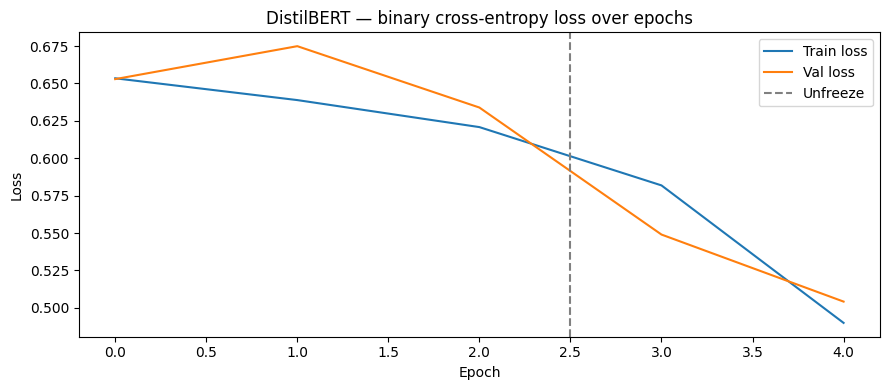

--- DistilBERT (validation) ---
              precision    recall  f1-score   support

          No      0.738     0.849     0.790       126
         Yes      0.655     0.486     0.558        74

    accuracy                          0.715       200
   macro avg      0.696     0.668     0.674       200
weighted avg      0.707     0.715     0.704       200



In [34]:
# Stage 2: unfreeze backbone and fine-tune end-to-end at lower lr
for p in bert_model.backbone.parameters():
    p.requires_grad = True

optimizer2 = Adam(bert_model.parameters(), lr=5e-6)
hist2_train_loss, hist2_val_loss = [], []
print("Stage 2: fine-tuning full network (backbone unfrozen, lr=5e-6)…")
for epoch in range(2):
    tr_loss, tr_acc = run_epoch(bert_model, train_bert_loader, optimizer2)
    vl_loss, vl_acc = run_epoch(bert_model, val_bert_loader)
    hist2_train_loss.append(tr_loss); hist2_val_loss.append(vl_loss)
    print(f"  Epoch {epoch+1} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {vl_loss:.4f} acc {vl_acc:.4f}")

plt.figure(figsize=(9, 4))
combined_train = hist1_train_loss + hist2_train_loss
combined_val   = hist1_val_loss   + hist2_val_loss
plt.plot(combined_train, label="Train loss")
plt.plot(combined_val,   label="Val loss")
plt.axvline(x=len(hist1_train_loss) - 0.5, color="gray", linestyle="--", label="Unfreeze")
plt.title("DistilBERT — binary cross-entropy loss over epochs")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()

bert_model.eval()
all_preds = []
with torch.no_grad():
    for input_ids, attention_mask, _ in val_bert_loader:
        logits = bert_model(input_ids.to(DEVICE), attention_mask.to(DEVICE))
        all_preds.extend((logits.sigmoid() > 0.5).long().cpu().numpy())

bert_preds = np.where(np.array(all_preds) == 1, "Yes", "No")
print("--- DistilBERT (validation) ---")
print(classification_report(bert_val_pool["class_action_sought"].values, bert_preds, digits=3))

## 9. Classification — `case_type`

Multi-class task. The raw label has 30+ values with a long tail. We follow the standard "top-N + Other" reduction (documented in `case_type_map.json`) to produce **6 well-populated classes**, then run the same model progression as §7 plus a confusion matrix.

In [35]:
import json
from pathlib import Path

TOP_N = 5
# Identify top-N case types using the train split only (avoids label leakage from val/test)
type_counts_train = df.loc[(df["split"] == "train") & df["case_type"].notna(), "case_type"].value_counts()
top_types = list(type_counts_train.head(TOP_N).index)

case_type_map = {t: t for t in top_types}      # top-N preserved
# Persist the mapping decision so it can be reused by the interactive tool / downstream models
Path("case_type_map.json").write_text(json.dumps({"top_types": top_types, "fallback": "Other"}, indent=2))

def map_case_type(t):
    return t if isinstance(t, str) and t in top_types else "Other"

ct_mask = df["case_type"].notna() & (df["clean_text"].str.len() > 50)
ct_df = df[ct_mask].copy()
ct_df["case_type_grouped"] = ct_df["case_type"].apply(map_case_type)

Xt_train, yt_train = ct_df.loc[ct_df["split"] == "train",      "clean_text"], ct_df.loc[ct_df["split"] == "train",      "case_type_grouped"]
Xt_val,   yt_val   = ct_df.loc[ct_df["split"] == "validation", "clean_text"], ct_df.loc[ct_df["split"] == "validation", "case_type_grouped"]
Xt_test,  yt_test  = ct_df.loc[ct_df["split"] == "test",       "clean_text"], ct_df.loc[ct_df["split"] == "test",       "case_type_grouped"]

print(f"Grouped label distribution (train):\n{yt_train.value_counts()}\n")
print(f"Top types kept: {top_types}")

Xt_train_tfidf = vectorizer.transform(Xt_train)
Xt_val_tfidf   = vectorizer.transform(Xt_val)
Xt_test_tfidf  = vectorizer.transform(Xt_test)

nb_type = MultinomialNB()
nb_type.fit(Xt_train_tfidf, yt_train)
print("--- Naive Bayes (validation) ---")
print(classification_report(yt_val, nb_type.predict(Xt_val_tfidf), digits=3))

lr_type = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced")
lr_type.fit(Xt_train_tfidf, yt_train)
print("--- Logistic Regression (validation) ---")
print(classification_report(yt_val, lr_type.predict(Xt_val_tfidf), digits=3))

print("\n=== Held-out TEST accuracy ===")
for name, m in [("Naive Bayes", nb_type), ("Logistic Regression", lr_type)]:
    print(f"  {name:<22} {m.score(Xt_test_tfidf, yt_test):.3f}")

Grouped label distribution (train):
case_type_grouped
Equal Employment                         1099
Other                                     971
Immigration and/or the Border             367
Prison Conditions                         313
Jail Conditions                           223
Public Benefits / Government Services     204
Name: count, dtype: int64

Top types kept: ['Equal Employment', 'Immigration and/or the Border ', 'Prison Conditions', 'Jail Conditions', 'Public Benefits / Government Services']
--- Naive Bayes (validation) ---
                                       precision    recall  f1-score   support

                     Equal Employment      0.918     0.935     0.927       155
       Immigration and/or the Border       0.926     0.833     0.877        60
                      Jail Conditions      0.786     0.500     0.611        22
                                Other      0.718     0.819     0.765       155
                    Prison Conditions      0.625     0.833    

Epoch  1 | train_acc 0.6003 | val_acc 0.7775
Epoch  2 | train_acc 0.8247 | val_acc 0.8590
Epoch  3 | train_acc 0.9084 | val_acc 0.9361
Epoch  4 | train_acc 0.9484 | val_acc 0.9295
Epoch  5 | train_acc 0.9625 | val_acc 0.9317
Epoch  6 | train_acc 0.9783 | val_acc 0.9339
Epoch  7 | train_acc 0.9893 | val_acc 0.9383
Epoch  8 | train_acc 0.9928 | val_acc 0.9471
Epoch  9 | train_acc 0.9946 | val_acc 0.9339
Epoch 10 | train_acc 0.9965 | val_acc 0.9427


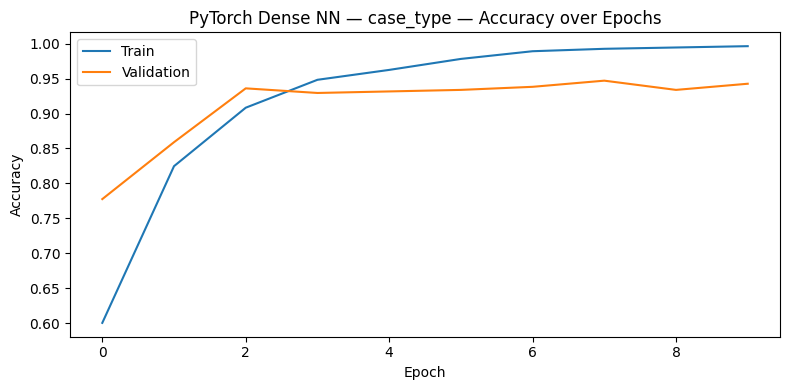

--- PyTorch Dense NN (validation) ---
                                       precision    recall  f1-score   support

                     Equal Employment      0.994     0.994     0.994       155
       Immigration and/or the Border       0.933     0.933     0.933        60
                      Jail Conditions      0.769     0.909     0.833        22
                                Other      0.936     0.942     0.939       155
                    Prison Conditions      0.963     0.867     0.912        30
Public Benefits / Government Services      0.867     0.812     0.839        32

                             accuracy                          0.943       454
                            macro avg      0.910     0.910     0.908       454
                         weighted avg      0.944     0.943     0.943       454

Test accuracy: 0.945


In [36]:
le_type = LabelEncoder()
yt_train_enc = le_type.fit_transform(yt_train)
yt_val_enc   = le_type.transform(yt_val)
yt_test_enc  = le_type.transform(yt_test)

Xt_train_dense = torch.tensor(Xt_train_tfidf.toarray().astype("float32"))
Xt_val_dense   = torch.tensor(Xt_val_tfidf.toarray().astype("float32"))
Xt_test_dense  = torch.tensor(Xt_test_tfidf.toarray().astype("float32"))

train_type_ds     = TensorDataset(Xt_train_dense, torch.tensor(yt_train_enc, dtype=torch.long))
val_type_ds       = TensorDataset(Xt_val_dense,   torch.tensor(yt_val_enc,   dtype=torch.long))
train_type_loader = DataLoader(train_type_ds, batch_size=32, shuffle=True)
val_type_loader   = DataLoader(val_type_ds,   batch_size=32)

n_type_classes = len(le_type.classes_)

model_type = nn.Sequential(
    nn.Linear(n_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, n_type_classes),
)

criterion_type = nn.CrossEntropyLoss()
optimizer_type = optim.Adam(model_type.parameters())

type_train_accs, type_val_accs = [], []
for epoch in range(10):
    model_type.train()
    correct, total = 0, 0
    for Xb, yb in train_type_loader:
        optimizer_type.zero_grad()
        out = model_type(Xb)
        loss = criterion_type(out, yb)
        loss.backward()
        optimizer_type.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += len(yb)
    type_train_accs.append(correct / total)

    model_type.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_type_loader:
            out = model_type(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += len(yb)
    type_val_accs.append(correct / total)
    print(f"Epoch {epoch+1:2d} | train_acc {type_train_accs[-1]:.4f} | val_acc {type_val_accs[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(type_train_accs, label="Train")
plt.plot(type_val_accs,   label="Validation")
plt.title("PyTorch Dense NN — case_type — Accuracy over Epochs")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.tight_layout(); plt.show()

model_type.eval()
with torch.no_grad():
    preds_val_type  = le_type.inverse_transform(model_type(Xt_val_dense).argmax(1).numpy())
    preds_test_type = le_type.inverse_transform(model_type(Xt_test_dense).argmax(1).numpy())

print("--- PyTorch Dense NN (validation) ---")
print(classification_report(yt_val, preds_val_type, digits=3))
print(f"Test accuracy: {(preds_test_type == yt_test.values).mean():.3f}")

### 9.1 Confusion matrix & per-class coefficient table

Two diagnostic deliverables for the presentation:

- **Confusion matrix (LR, validation set):** shows *which* classes the model confuses, not just overall accuracy. Common failure mode in legal-text classification is the "Other" bucket absorbing minority classes — the matrix surfaces this directly.
- **Top-5 most-predictive terms per class:** the linguistic evidence the model uses to assign each `case_type`. Reads like an answer to "how does the model tell *Equal Employment* from *Prison Conditions*?".

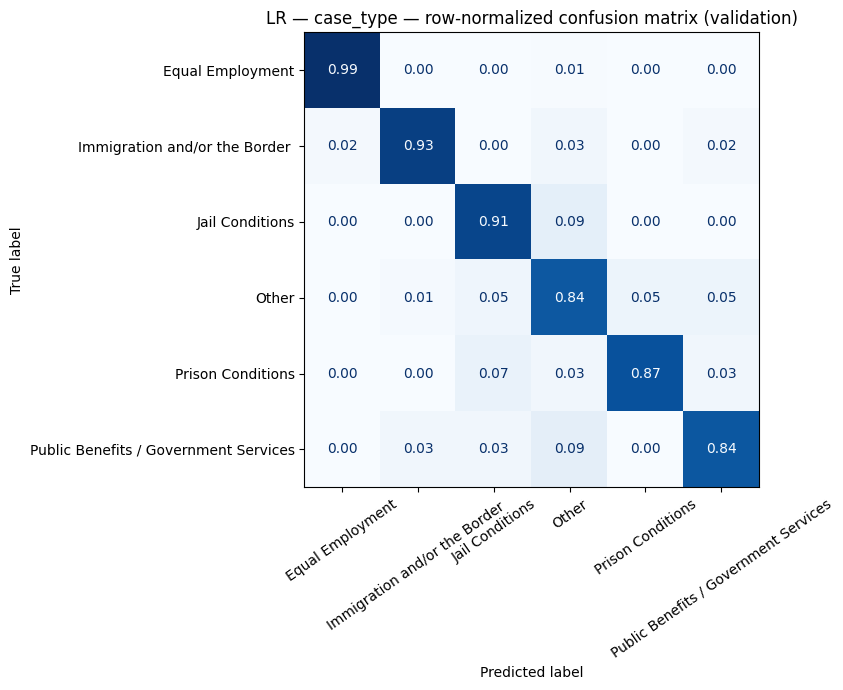

=== Top 5 predictive bigrams per case_type ===
  Equal Employment                         eeoc (+2.12), equal employment (+2.11), employment opportunity (+1.99), title vii (+1.98), opportunity commission (+1.90)
  Immigration and/or the Border            immigration (+3.97), immigrant (+2.98), alien (+2.82), immigration law (+2.28), ice (+2.26)
  Jail Conditions                          jail (+4.38), county jail (+3.59), sheriff (+3.29), inmate (+2.59), county sheriff (+2.50)
  Other                                    fair housing (+1.26), student (+1.18), youth (+1.08), probable cause (+0.98), arrest (+0.89)
  Prison Conditions                        department correction (+3.13), prisoner (+2.87), correctional (+2.85), prison (+2.85), inmate (+2.55)
  Public Benefits / Government Services    medicaid (+2.26), samesex (+1.91), marriage (+1.84), samesex couple (+1.70), samesex marriage (+1.49)


In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# --- Confusion matrix for LR on validation ---
labels_in_order = sorted(lr_type.classes_)
cm = confusion_matrix(yt_val, lr_type.predict(Xt_val_tfidf), labels=labels_in_order, normalize="true")

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=labels_in_order)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f", xticks_rotation=35)
ax.set_title("LR — case_type — row-normalized confusion matrix (validation)")
plt.tight_layout(); plt.show()

# --- Top terms per class (LR coefficients) ---
feature_names = vectorizer.get_feature_names_out()
print("=== Top 5 predictive bigrams per case_type ===")
for cls_idx, cls in enumerate(lr_type.classes_):
    coef = lr_type.coef_[cls_idx]
    top_idx = coef.argsort()[-5:][::-1]
    terms = ", ".join(f"{feature_names[i]} ({coef[i]:+.2f})" for i in top_idx)
    print(f"  {cls:<40} {terms}")

## 10. Interactive Tool (Notebook Widget)

End-to-end demo: paste a legal case → strip boilerplate → NLTK-normalize → TF-IDF extractive excerpt → cascade BART summaries → LR predictions with confidence.

For the standalone Gradio app (Dockerized, cross-platform), see [`../Interactive_Tool/`](../Interactive_Tool/).

In [38]:
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

text_input = widgets.Textarea(
    placeholder="Paste a legal case description here...",
    layout=widgets.Layout(width="100%", height="220px"),
)
run_btn = widgets.Button(description="Analyze Case", button_style="primary", icon="search")
output_area = widgets.Output()

def _bar(p: float, width: int = 20) -> str:
    n = round(p * width)
    return "█" * n + "░" * (width - n)

def on_analyze(_):
    with output_area:
        clear_output(wait=True)
        raw = text_input.value.strip()
        if not raw:
            print("Please enter a legal case description.")
            return

        prepped = strip_legal_boilerplate(raw)
        cleaned = clean_text(prepped)
        excerpt = build_excerpt(prepped)

        if len(cleaned) < 50:
            print("Input is too short for reliable analysis (need ~50+ chars of legal text).")
            return

        vec = vectorizer.transform([cleaned])
        sums = generate_summaries(excerpt)

        action_probs = dict(zip(lr.classes_,      lr.predict_proba(vec)[0]))
        type_probs   = dict(zip(lr_type.classes_, lr_type.predict_proba(vec)[0]))
        pred_action = max(action_probs, key=action_probs.get)
        pred_type   = max(type_probs,   key=type_probs.get)

        action_bars = "\n".join(
            f"`{_bar(p)}` {p*100:5.1f}%  {label}"
            for label, p in sorted(action_probs.items(), key=lambda kv: -kv[1])
        )
        type_bars = "\n".join(
            f"`{_bar(p)}` {p*100:5.1f}%  {label}"
            for label, p in sorted(type_probs.items(), key=lambda kv: -kv[1])
        )

        display(Markdown(f"""
### Predictions

**Class action sought:** `{pred_action}`

{action_bars}

**Case type:** `{pred_type}`

{type_bars}

---

### Summaries (DistilBART cascade)

**Long**  
{sums['long']}

**Short**  
{sums['short']}

**Tiny**  
{sums['tiny']}
"""))

run_btn.on_click(on_analyze)
display(widgets.VBox([text_input, run_btn, output_area]))

## 11. Word Clouds of LR Coefficients

Visual companion to the coefficient-polarity tables in §7.1 and §9.1. Word clouds render the same information for the presentation slide — they are eye-catching but the underlying numbers (log-odds) are what matters.

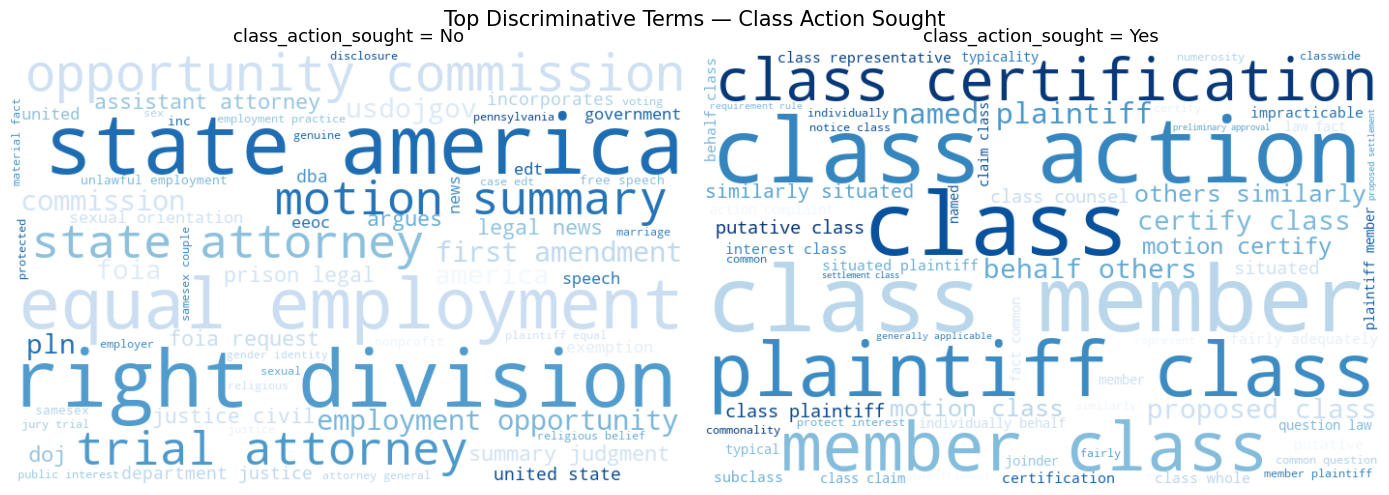

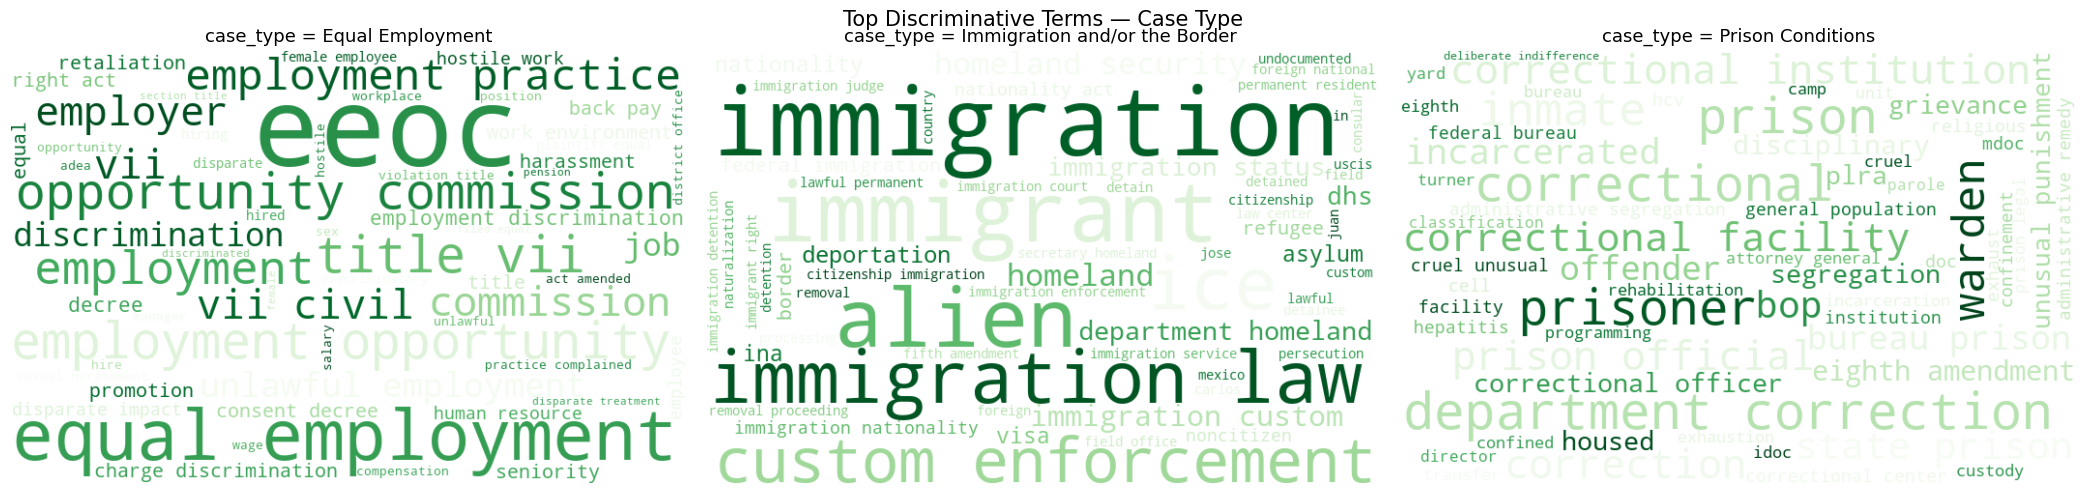

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

feature_names = vectorizer.get_feature_names_out()

# Word clouds for class_action_sought (LR log-odds coefficients)
classes = lr.classes_
coef_matrix = np.vstack([-lr.coef_[0], lr.coef_[0]]) if len(classes) == 2 else lr.coef_

fig, axes = plt.subplots(1, len(classes), figsize=(7 * len(classes), 5))
axes = [axes] if len(classes) == 1 else axes
for ax, cls, coef in zip(axes, classes, coef_matrix):
    top_idx = coef.argsort()[-60:]
    top_words = {feature_names[i]: float(coef[i]) for i in top_idx if coef[i] > 0}
    wc = WordCloud(width=700, height=450, background_color='white', colormap='Blues')
    wc.generate_from_frequencies(top_words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'class_action_sought = {cls}', fontsize=13)
    ax.axis('off')
plt.suptitle("Top Discriminative Terms — Class Action Sought", fontsize=15)
plt.tight_layout()
plt.show()

# Word clouds for the top 3 case types
fig2, axes2 = plt.subplots(1, min(3, TOP_N), figsize=(7 * min(3, TOP_N), 5))
for ax, cls in zip(axes2, list(top_types)[:3]):
    if cls not in lr_type.classes_:
        continue
    idx = list(lr_type.classes_).index(cls)
    coef = lr_type.coef_[idx]
    top_idx = coef.argsort()[-60:]
    top_words = {feature_names[i]: float(coef[i]) for i in top_idx if coef[i] > 0}
    wc = WordCloud(width=700, height=450, background_color='white', colormap='Greens')
    wc.generate_from_frequencies(top_words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'case_type = {cls}', fontsize=13)
    ax.axis('off')
plt.suptitle("Top Discriminative Terms — Case Type", fontsize=15)
plt.tight_layout()
plt.show()